In [ ]:
!pip install -q giotto-tda

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.6/554.6 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.8/455.8 kB 10.2 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from gtda.homology import VietorisRipsPersistence
from scipy.stats import wasserstein_distance
from sklearn.preprocessing import StandardScaler

# Función para cargar datos, calcular el diagrama de persistencia y devolver el diagrama
def calculate_persistence_diagram(file_path, dist_column):
    df = pd.read_csv(file_path)

    # Dividir los valores de la columna de distancia por 1000
    df[dist_column] = df[dist_column] / 1000

    # Incluimos 'crime_lon', 'crime_lat' y la columna de distancias en los datos
    data = df[['crime_lon', 'crime_lat', dist_column]].dropna().values  # Eliminar filas con NaN
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data)

    VR = VietorisRipsPersistence()
    diagrams = VR.fit_transform([data_scaled])

    return diagrams[0]  # Diagrama de persistencia para el primer dataset

# Función para calcular la distancia de Wasserstein entre dos diagramas
def wasserstein_distance_between_diagrams(diag1, diag2):
    # Extraer las coordenadas de nacimiento y muerte
    births1, deaths1 = diag1[:, 0], diag1[:, 1]
    births2, deaths2 = diag2[:, 0], diag2[:, 1]

    # Asegúrate de que ambos diagramas tengan el mismo tamaño
    max_len = max(len(births1), len(births2))
    births1 = np.pad(births1, (0, max_len - len(births1)), constant_values=np.nan)
    deaths1 = np.pad(deaths1, (0, max_len - len(deaths1)), constant_values=np.nan)
    births2 = np.pad(births2, (0, max_len - len(births2)), constant_values=np.nan)
    deaths2 = np.pad(deaths2, (0, max_len - len(deaths2)), constant_values=np.nan)

    # Calcular la distancia de Wasserstein para las coordenadas de nacimiento y muerte
    distance_births = wasserstein_distance(births1[~np.isnan(births1)], births2[~np.isnan(births2)])
    distance_deaths = wasserstein_distance(deaths1[~np.isnan(deaths1)], deaths2[~np.isnan(deaths2)])

    # Combinar las distancias (puedes ajustar este paso si es necesario)
    return distance_births + distance_deaths

# Lista de distancias
dist = ['atm_dist', 'bank_dist', 'bar_dist', 'cafe_dist', 'industrial_dist',
        'market_dist', 'nightclub_dist', 'police_dist', 'pub_dist',
        'restaurant_dist', 'taxi_dist']

#HEAD CHECK
# Archivo CSV
file_path = 'Valencia_2015.csv'

# Calcular diagramas de persistencia para cada columna de distancias
diagrams = {}
for d in dist:
    diagrams[d] = calculate_persistence_diagram(file_path, d)

# Calcular distancias de Wasserstein entre los diagramas usando las distancias
dist_matrix = np.zeros((len(dist), len(dist)))

for i in range(len(dist)):
    for j in range(i + 1, len(dist)):
        dist_val = wasserstein_distance_between_diagrams(diagrams[dist[i]], diagrams[dist[j]])
        dist_matrix[i, j] = dist_val
        dist_matrix[j, i] = dist_val

# Mostrar la matriz de distancias
print("Matriz de distancias de Wasserstein entre diagramas de persistencia:")
print(dist_matrix)



Matriz de distancias de Wasserstein entre diagramas de persistencia:
[[0.         0.04336835 0.01769141 0.01918905 0.00655904 0.01354757
  0.00637806 0.00760219 0.01483227 0.03971083 0.01002539]
 [0.04336835 0.         0.02630602 0.02529299 0.04917433 0.05687261
  0.04922773 0.05084283 0.02902682 0.00895511 0.03478193]
 [0.01769141 0.02630602 0.         0.00382619 0.02289703 0.03063285
  0.02324808 0.0246454  0.00469981 0.02233497 0.01018855]
 [0.01918905 0.02529299 0.00382619 0.         0.02400625 0.03179871
  0.02454722 0.02579367 0.00637592 0.02116629 0.01198488]
 [0.00655904 0.04917433 0.02289703 0.02400625 0.         0.00816336
  0.00411594 0.00443623 0.02039858 0.04514274 0.01635228]
 [0.01354757 0.05687261 0.03063285 0.03179871 0.00816336 0.
  0.00767302 0.00762152 0.02821567 0.05296008 0.02253731]
 [0.00637806 0.04922773 0.02324808 0.02454722 0.00411594 0.00767302
  0.         0.00361797 0.02056092 0.04537689 0.01509025]
 [0.00760219 0.05084283 0.0246454  0.02579367 0.00443623 

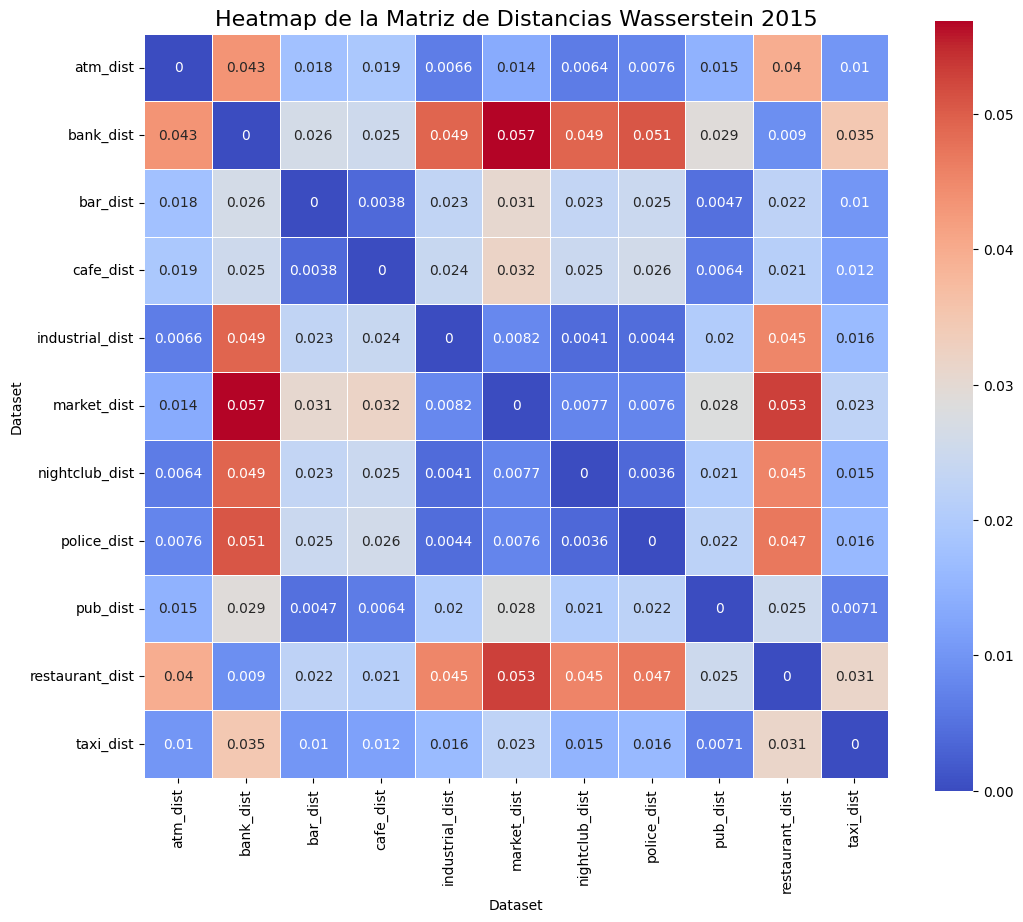

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Nueva matriz de distancias Wasserstein
dist_matrix_wasserstein = np.array([
    [0.0, 0.04336835, 0.01769141, 0.01918905, 0.00655904, 0.01354757, 0.00637806, 0.00760219, 0.01483227, 0.03971083, 0.01002539],
    [0.04336835, 0.0, 0.02630602, 0.02529299, 0.04917433, 0.05687261, 0.04922773, 0.05084283, 0.02902682, 0.00895511, 0.03478193],
    [0.01769141, 0.02630602, 0.0, 0.00382619, 0.02289703, 0.03063285, 0.02324808, 0.0246454, 0.00469981, 0.02233497, 0.01018855],
    [0.01918905, 0.02529299, 0.00382619, 0.0, 0.02400625, 0.03179871, 0.02454722, 0.02579367, 0.00637592, 0.02116629, 0.01198488],
    [0.00655904, 0.04917433, 0.02289703, 0.02400625, 0.0, 0.00816336, 0.00411594, 0.00443623, 0.02039858, 0.04514274, 0.01635228],
    [0.01354757, 0.05687261, 0.03063285, 0.03179871, 0.00816336, 0.0, 0.00767302, 0.00762152, 0.02821567, 0.05296008, 0.02253731],
    [0.00637806, 0.04922773, 0.02324808, 0.02454722, 0.00411594, 0.00767302, 0.0, 0.00361797, 0.02056092, 0.04537689, 0.01509025],
    [0.00760219, 0.05084283, 0.0246454, 0.02579367, 0.00443623, 0.00762152, 0.00361797, 0.0, 0.02218932, 0.04693379, 0.01606756],
    [0.01483227, 0.02902682, 0.00469981, 0.00637592, 0.02039858, 0.02821567, 0.02056092, 0.02218932, 0.0, 0.0249645, 0.00706951],
    [0.03971083, 0.00895511, 0.02233497, 0.02116629, 0.04514274, 0.05296008, 0.04537689, 0.04693379, 0.0249645, 0.0, 0.03137999],
    [0.01002539, 0.03478193, 0.01018855, 0.01198488, 0.01635228, 0.02253731, 0.01509025, 0.01606756, 0.00706951, 0.03137999, 0.0]
])

# Nombres de los archivos CSV
csv_names = ['atm_dist', 'bank_dist', 'bar_dist', 'cafe_dist', 'industrial_dist',
        'market_dist', 'nightclub_dist', 'police_dist', 'pub_dist',
        'restaurant_dist', 'taxi_dist']

# Crear un heatmap utilizando seaborn
plt.figure(figsize=(12, 10))
sns.heatmap(dist_matrix_wasserstein, annot=True, cmap="coolwarm", cbar=True, square=True, linewidths=.5,
            xticklabels=csv_names, yticklabels=csv_names)

# Añadir etiquetas a los ejes
plt.title('Heatmap de la Matriz de Distancias Wasserstein 2015', fontsize=16)
plt.xlabel('Dataset')
plt.ylabel('Dataset')

# Mostrar el heatmap
plt.show()


In [ ]:
!pip install gudhi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 29.6 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from gtda.homology import VietorisRipsPersistence
from gudhi import bottleneck_distance
from sklearn.preprocessing import StandardScaler

# Función para cargar datos, calcular el diagrama de persistencia y devolver solo nacimiento y muerte
def calculate_persistence_diagram(file_path, dist_column):
    df = pd.read_csv(file_path)

    # Dividir la columna de distancia por 1000
    df[dist_column] = df[dist_column] / 1000

    # Usar 'crime_lon', 'crime_lat' y la columna de distancia
    data = df[['crime_lon', 'crime_lat', dist_column]].dropna().values  # Eliminar filas con NaN
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data)

    VR = VietorisRipsPersistence()
    diagrams = VR.fit_transform([data_scaled])

    # Filtrar el diagrama para solo incluir las columnas de nacimiento y muerte (dim 0 para H0, dim 1 para H1)
    persistence_diagram = diagrams[0][:, :2]  # Tomar solo las primeras dos columnas: nacimiento y muerte
    return persistence_diagram

# Función para calcular la distancia Bottleneck entre dos diagramas
def bottleneck_distance_between_diagrams(diag1, diag2):
    return bottleneck_distance(diag1, diag2)

# Lista de distancias
dist = ['atm_dist', 'bank_dist', 'bar_dist', 'cafe_dist', 'industrial_dist',
        'market_dist', 'nightclub_dist', 'police_dist', 'pub_dist',
        'restaurant_dist', 'taxi_dist']

# Archivo CSV
file_path = 'Valencia_2015.csv'

# Calcular diagramas de persistencia para cada columna de distancias
diagrams = {}
for d in dist:
    diagrams[d] = calculate_persistence_diagram(file_path, d)

# Calcular distancias Bottleneck entre los diagramas usando las distancias
dist_matrix = np.zeros((len(dist), len(dist)))

for i in range(len(dist)):
    for j in range(i + 1, len(dist)):
        dist_val = bottleneck_distance_between_diagrams(diagrams[dist[i]], diagrams[dist[j]])
        dist_matrix[i, j] = dist_val
        dist_matrix[j, i] = dist_val

# Mostrar la matriz de distancias
print("Matriz de distancias Bottleneck entre diagramas de persistencia:")
print(dist_matrix)



Matriz de distancias Bottleneck entre diagramas de persistencia:
[[0.         1.93776143 0.55632734 0.93113601 0.14368397 0.2356565
  0.13604277 0.35236651 0.39426285 1.9912318  0.39795804]
 [1.93776143 0.         1.93776143 1.07120347 1.93776143 1.93776143
  1.93776143 1.89706409 1.70670962 0.795012   1.65484595]
 [0.55632734 1.93776143 0.         0.93186903 0.4710027  0.54224551
  0.5203715  0.39680952 0.33513522 1.9912318  0.38457555]
 [0.93113601 1.07120347 0.93186903 0.         0.97268176 1.05707026
  0.92722309 0.82586062 0.63550615 1.34937453 0.58364248]
 [0.14368397 1.93776143 0.4710027  0.97268176 0.         0.23329198
  0.19310257 0.20868254 0.35138237 1.9912318  0.48066199]
 [0.2356565  1.93776143 0.54224551 1.05707026 0.23329198 0.
  0.27461576 0.24554917 0.4336831  1.9912318  0.58514941]
 [0.13604277 1.93776143 0.5203715  0.92722309 0.19310257 0.27461576
  0.         0.33132207 0.37321842 1.9912318  0.3435806 ]
 [0.35236651 1.89706409 0.39680952 0.82586062 0.20868254 0.245

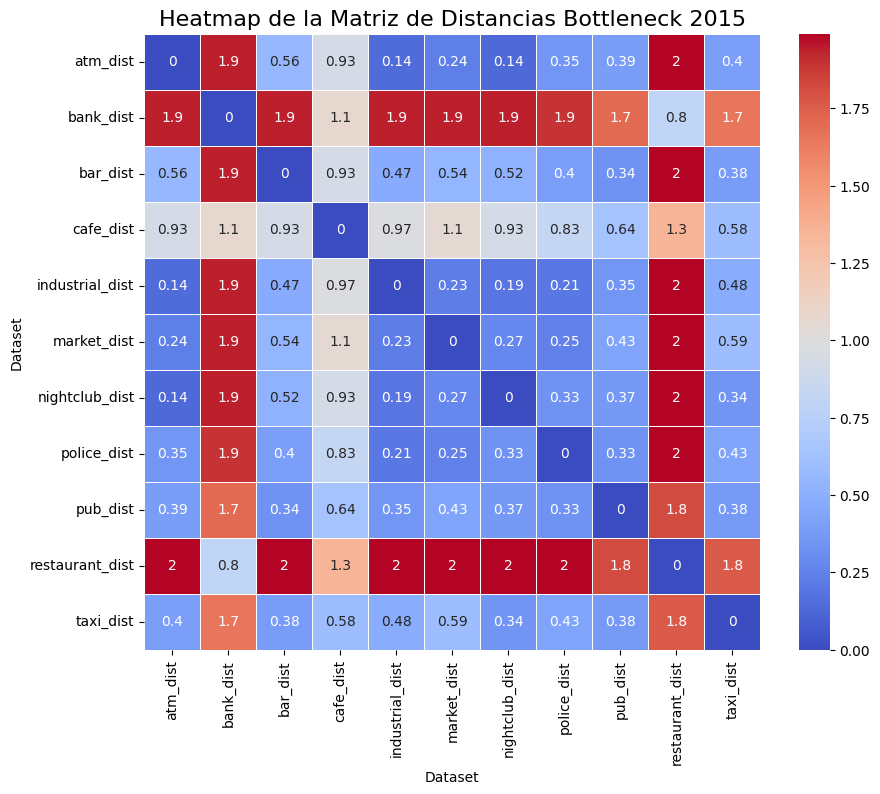

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Nueva matriz de distancias Bottleneck
dist_matrix_bottleneck = np.array([
    [0.0, 1.93776143, 0.55632734, 0.93113601, 0.14368397, 0.2356565, 0.13604277, 0.35236651, 0.39426285, 1.9912318, 0.39795804],
    [1.93776143, 0.0, 1.93776143, 1.07120347, 1.93776143, 1.93776143, 1.93776143, 1.89706409, 1.70670962, 0.795012, 1.65484595],
    [0.55632734, 1.93776143, 0.0, 0.93186903, 0.4710027, 0.54224551, 0.5203715, 0.39680952, 0.33513522, 1.9912318, 0.38457555],
    [0.93113601, 1.07120347, 0.93186903, 0.0, 0.97268176, 1.05707026, 0.92722309, 0.82586062, 0.63550615, 1.34937453, 0.58364248],
    [0.14368397, 1.93776143, 0.4710027, 0.97268176, 0.0, 0.23329198, 0.19310257, 0.20868254, 0.35138237, 1.9912318, 0.48066199],
    [0.2356565, 1.93776143, 0.54224551, 1.05707026, 0.23329198, 0.0, 0.27461576, 0.24554917, 0.4336831, 1.9912318, 0.58514941],
    [0.13604277, 1.93776143, 0.5203715, 0.92722309, 0.19310257, 0.27461576, 0.0, 0.33132207, 0.37321842, 1.9912318, 0.3435806],
    [0.35236651, 1.89706409, 0.39680952, 0.82586062, 0.20868254, 0.24554917, 0.33132207, 0.0, 0.33449131, 1.9912318, 0.43318105],
    [0.39426285, 1.70670962, 0.33513522, 0.63550615, 0.35138237, 0.4336831, 0.37321842, 0.33449131, 0.0, 1.81365037, 0.37803912],
    [1.9912318, 0.795012, 1.9912318, 1.34937453, 1.9912318, 1.9912318, 1.9912318, 1.9912318, 1.81365037, 0.0, 1.7617867],
    [0.39795804, 1.65484595, 0.38457555, 0.58364248, 0.48066199, 0.58514941, 0.3435806, 0.43318105, 0.37803912, 1.7617867, 0.0]
])

# Nombres de los archivos CSV
csv_names = ['atm_dist', 'bank_dist', 'bar_dist', 'cafe_dist', 'industrial_dist',
        'market_dist', 'nightclub_dist', 'police_dist', 'pub_dist',
        'restaurant_dist', 'taxi_dist']

# Crear un heatmap utilizando seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(dist_matrix_bottleneck, annot=True, cmap="coolwarm", cbar=True, square=True, linewidths=.5,
            xticklabels=csv_names, yticklabels=csv_names)

# Añadir etiquetas a los ejes
plt.title('Heatmap de la Matriz de Distancias Bottleneck 2015', fontsize=16)
plt.xlabel('Dataset')
plt.ylabel('Dataset')

# Mostrar el heatmap
plt.show()
